   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.4 MB/s eta 0:00:00

  PART 1: TRAINING CUSTOM CBOW & SKIP-GRAM MODELS
✓ CBOW Model Trained Successfully (sg=0)
✓ Skip-gram Model Trained Successfully (sg=1)

--- Semantic Similarities using CBOW ---
Similarity ('queen', 'king'): 0.2136
Similarity ('apple', 'is'): 0.0366
Similarity of unrelated words ('queen', 'apple'): -0.2266

--- Semantic Similarities using Skip-gram ---
Similarity ('queen', 'king'): 0.2112
Similarity ('apple', 'is'): 0.0347
Similarity of unrelated words ('queen', 'apple'): -0.2282

  PART 2: LOADING PRE-TRAINED GOOGLE NEWS 300D VECTORS
Loading 'word2vec-google-news-300' (takes a few moments on first download)...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
✓ Model loaded. Vocabulary size: 3,000,000 words.

--- Top 5 Words Most Similar to 'google' ---
google.com: 0.6711
google_yahoo: 0.6488
wikipedia: 0.6436
www.google.com: 0.6259
googled: 0.6166

  PART 3: VECTOR AR

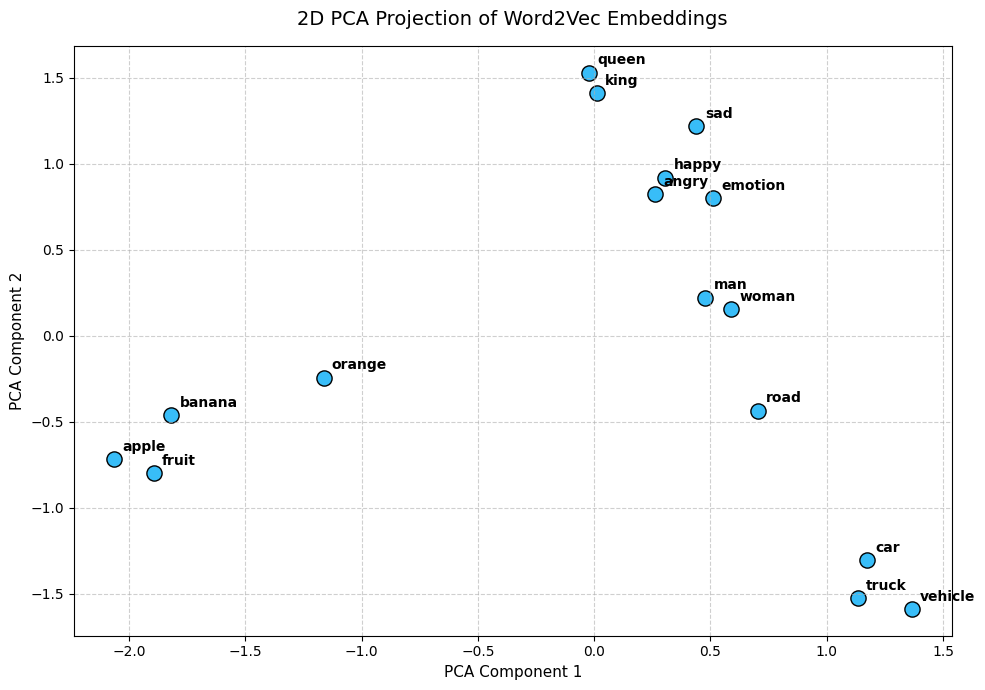


  PART 5: GENERATING PAIRWISE SIMILARITY HEATMAP
Similarity Matrix:
         king   queen     man   woman
king   1.0000  0.6511  0.2294  0.1285
queen  0.6511  1.0000  0.1666  0.3162
man    0.2294  0.1666  1.0000  0.7664
woman  0.1285  0.3162  0.7664  1.0000
✓ Saved interactive heatmap to 'assets/similarity_heatmap.html'


In [ ]:
# ==============================================================================
# PRACTICAL 03: WORD EMBEDDINGS, VECTOR ARITHMETIC & SIMILARITY VISUALIZATIONS
# Author: Shreya Nimje
# ==============================================================================

!pip install gensim

import os
import gensim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from gensim.models import Word2Vec
import gensim.downloader as api
from sklearn.decomposition import PCA


def print_section(title):
    print(f"\n{'=' * 65}")
    print(f"  {title}")
    print(f"{'=' * 65}")


# ==============================================================================
# PART 1: TOY DATASET TRAINING (CBOW VS SKIP-GRAM)
# ==============================================================================
def train_custom_embeddings():
    print_section("PART 1: TRAINING CUSTOM CBOW & SKIP-GRAM MODELS")

    sentences = [
        ['the', 'king', 'rules', 'the', 'kingdom'],
        ['the', 'prince', 'rules', 'the', 'kingdom'],
        ['the', 'queen', 'rules', 'the', 'kingdom'],
        ['an', 'apple', 'is', 'a', 'tasty', 'fruit'],
        ['a', 'banana', 'is', 'a', 'tasty', 'fruit'],
        ['a', 'cherry', 'is', 'a', 'tasty', 'fruit']
    ]

    # Continuous Bag of Words (CBOW: sg=0)
    model_cbow = Word2Vec(sentences, vector_size=10, window=2, min_count=1, sg=0, epochs=100)
    print("✓ CBOW Model Trained Successfully (sg=0)")

    # Skip-Gram (sg=1)
    model_skipgram = Word2Vec(sentences, vector_size=10, window=2, min_count=1, sg=1, epochs=100)
    print("✓ Skip-gram Model Trained Successfully (sg=1)")

    def evaluate_similarities(model, model_name):
        print(f"\n--- Semantic Similarities using {model_name} ---")
        sim_royal = model.wv.similarity('queen', 'king')
        print(f"Similarity ('queen', 'king'): {sim_royal:.4f}")

        sim_fruit = model.wv.similarity('apple', 'is')
        print(f"Similarity ('apple', 'is'): {sim_fruit:.4f}")

        sim_unrelated = model.wv.similarity('queen', 'apple')
        print(f"Similarity of unrelated words ('queen', 'apple'): {sim_unrelated:.4f}")

    evaluate_similarities(model_cbow, "CBOW")
    evaluate_similarities(model_skipgram, "Skip-gram")


# ==============================================================================
# PART 2: PRE-TRAINED EMBEDDINGS (GOOGLE NEWS 300) & VECTOR ARITHMETIC
# ==============================================================================
def explore_pretrained_model():
    print_section("PART 2: LOADING PRE-TRAINED GOOGLE NEWS 300D VECTORS")
    print("Loading 'word2vec-google-news-300' (takes a few moments on first download)...")

    model = api.load("word2vec-google-news-300")
    print(f"✓ Model loaded. Vocabulary size: {len(model.key_to_index):,} words.")

    # Nearest Neighbors
    print("\n--- Top 5 Words Most Similar to 'google' ---")
    for word, score in model.most_similar("google", topn=5):
        print(f"{word}: {score:.4f}")

    # Vector Arithmetic: King - Man + Woman = Queen
    print_section("PART 3: VECTOR ARITHMETIC & LINGUISTIC ANALOGIES")
    print("Formula: King - Man + Woman = ?")
    analogy_results = model.most_similar(
        positive=['king', 'woman'],
        negative=['man'],
        topn=5
    )
    for word, score in analogy_results:
        print(f"Result -> {word}: {score:.4f}")

    return model


# ==============================================================================
# PART 4: PCA 2D SCATTER PLOT VISUALIZATION
# ==============================================================================
def plot_pca_clusters(model):
    print_section("PART 4: GENERATING 2D PCA CLUSTER SCATTER PLOT")

    words_to_visualize = [
        'king', 'queen', 'man', 'woman',
        'apple', 'banana', 'orange', 'fruit',
        'car', 'truck', 'vehicle', 'road',
        'happy', 'sad', 'angry', 'emotion'
    ]

    filtered_words = [w for w in words_to_visualize if w in model.key_to_index]
    vectors = [model[w] for w in filtered_words]

    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 7))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], edgecolors='k', c='#38bdf8', s=120)

    for i, word in enumerate(filtered_words):
        plt.annotate(
            word,
            (vectors_2d[i, 0], vectors_2d[i, 1]),
            textcoords="offset points",
            xytext=(6, 6),
            ha='left',
            fontweight='bold'
        )

    plt.title("2D PCA Projection of Word2Vec Embeddings", fontsize=14, pad=15)
    plt.xlabel("PCA Component 1", fontsize=11)
    plt.ylabel("PCA Component 2", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    os.makedirs("assets", exist_ok=True)
    plt.savefig("assets/pca_clusters.png", dpi=300)
    print("✓ Saved PCA cluster plot to 'assets/pca_clusters.png'")
    plt.show()


# ==============================================================================
# PART 5: INTERACTIVE PAIRWISE HEATMAP (PLOTLY)
# ==============================================================================
def plot_similarity_heatmap(model):
    print_section("PART 5: GENERATING PAIRWISE SIMILARITY HEATMAP")

    words = ['king', 'queen', 'man', 'woman']
    similarity_matrix = pd.DataFrame(index=words, columns=words, dtype=float)

    for i in range(len(words)):
        for j in range(len(words)):
            similarity_matrix.iloc[i, j] = model.similarity(words[i], words[j])

    print("Similarity Matrix:")
    print(similarity_matrix.round(4))

    fig = px.imshow(
        similarity_matrix,
        text_auto=".4f",
        aspect="auto",
        color_continuous_scale="RdBu_r",
        title="Word Embedding Pairwise Cosine Similarity Matrix"
    )
    fig.update_layout(
        xaxis_title="Tokens",
        yaxis_title="Tokens",
        title_x=0.5
    )

    fig.write_html("assets/similarity_heatmap.html")
    print("✓ Saved interactive heatmap to 'assets/similarity_heatmap.html'")
    fig.show()


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    train_custom_embeddings()
    pretrained_model = explore_pretrained_model()
    plot_pca_clusters(pretrained_model)
    plot_similarity_heatmap(pretrained_model)